# **1. Descargar y Cargar Datos**

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage

In [40]:
df = pd.read_csv("us-counties.csv")

# **2. Exploracion Inicial**

In [41]:
#Exploracion inicial
print(df.head())

         date     county       state     fips  cases  deaths
0  2020-01-21  Snohomish  Washington  53061.0      1     0.0
1  2020-01-22  Snohomish  Washington  53061.0      1     0.0
2  2020-01-23  Snohomish  Washington  53061.0      1     0.0
3  2020-01-24       Cook    Illinois  17031.0      1     0.0
4  2020-01-24  Snohomish  Washington  53061.0      1     0.0


## **2.1 Verifica el tipo de datos de cada columna**

In [42]:
print(df.dtypes)

date          str
county        str
state         str
fips      float64
cases       int64
deaths    float64
dtype: object


# **2.2 Realizar resumen estadistico**

In [43]:
print(df.describe())

               fips         cases        deaths
count  2.479154e+06  2.502832e+06  2.445227e+06
mean   3.139958e+04  1.003380e+04  1.616100e+02
std    1.634251e+04  4.752522e+04  8.203335e+02
min    1.001000e+03  0.000000e+00  0.000000e+00
25%    1.902300e+04  3.820000e+02  6.000000e+00
50%    3.001100e+04  1.773000e+03  3.300000e+01
75%    4.611100e+04  5.884000e+03  1.010000e+02
max    7.803000e+04  2.908425e+06  4.026700e+04


# **3. IDENTIFICACION DE PROBLEMAS DE CALIDAD**

## **3.1 Identifica y cuenta valores faltantes de cada columna**

In [44]:
#Identificacion de problemas
print(df.isnull().sum())

date          0
county        0
state         0
fips      23678
cases         0
deaths    57605
dtype: int64


## **3.2 Codificación de variables categóricas**

In [45]:
df.columns = df.columns.str.strip().str.lower()

le_state = LabelEncoder()
le_county = LabelEncoder()

df['state_encoded'] = le_state.fit_transform(df['state'])
df['county_encoded'] = le_county.fit_transform(df['county'])

print(df[['state', 'state_encoded', 'county', 'county_encoded']].head())

        state  state_encoded     county  county_encoded
0  Washington             52  Snohomish            1601
1  Washington             52  Snohomish            1601
2  Washington             52  Snohomish            1601
3    Illinois             15       Cook             414
4  Washington             52  Snohomish            1601


## **3.3 Normalización de datos**

In [46]:
# Seleccionar columnas numéricas
numeric_cols = ['cases', 'deaths']

scaler = StandardScaler()

# Aplicar normalización
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print(df.head())

         date     county       state     fips     cases    deaths  \
0  2020-01-21  Snohomish  Washington  53061.0 -0.211105 -0.197005   
1  2020-01-22  Snohomish  Washington  53061.0 -0.211105 -0.197005   
2  2020-01-23  Snohomish  Washington  53061.0 -0.211105 -0.197005   
3  2020-01-24       Cook    Illinois  17031.0 -0.211105 -0.197005   
4  2020-01-24  Snohomish  Washington  53061.0 -0.211105 -0.197005   

   state_encoded  county_encoded  
0             52            1601  
1             52            1601  
2             52            1601  
3             15             414  
4             52            1601  


# **4. Seleccion de Caracteristicas (Opcional)**

## **4.1 Agrupar por condado (últimos valores)**

In [47]:
df_grouped = df.groupby("county").agg({
    "cases": "max",
    "deaths": "max"
}).reset_index()

## **4.2 Crear una característica nueva (evitando division por 0)**

In [48]:
df_grouped["fatality_rate"] = df_grouped["deaths"] / df_grouped["cases"]

# Reemplazar infinitos y NaN
df_grouped.replace([np.inf, -np.inf], 0, inplace=True)
df_grouped.fillna(0, inplace=True)

,county,cases,deaths,fatality_rate
0,Abbeville,-0.071095,-0.111674,1.570773
1,Acadia,0.123560,0.161386,1.306136
2,Accomack,-0.062699,-0.067790,1.081182
3,Ada,2.634922,1.048830,0.398050
4,Adair,-0.042773,-0.066571,1.556361
...,...,...,...,...
1927,Yukon-Koyukuk Census Area,-0.180868,-0.184815,1.021822
1928,Yuma,1.109247,1.242653,1.120268
1929,Zapata,-0.132178,-0.129959,0.983212
1930,Zavala,-0.125719,-0.114112,0.907679


## **4.3 Seleccionar SOLO las features relevantes**

In [49]:
features = df_grouped[["cases", "deaths", "fatality_rate"]]


## **4.4 Normalizar los datos (importante para clustering)**

In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# **5. Aplicación de la Técnica de Clúster**

## **5.1 Aplicar K-Means**

In [51]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_grouped["cluster"] = kmeans.fit_predict(X_scaled)

# **Ver resultado**

In [52]:
df_grouped.head()

,county,cases,deaths,fatality_rate,cluster
0,Abbeville,-0.071095,-0.111674,1.570773,0
1,Acadia,0.123560,0.161386,1.306136,0
2,Accomack,-0.062699,-0.067790,1.081182,0
3,Ada,2.634922,1.048830,0.398050,0
4,Adair,-0.042773,-0.066571,1.556361,0


# **6. Visualización de Resultados**

## **6.1 Scatter plot**

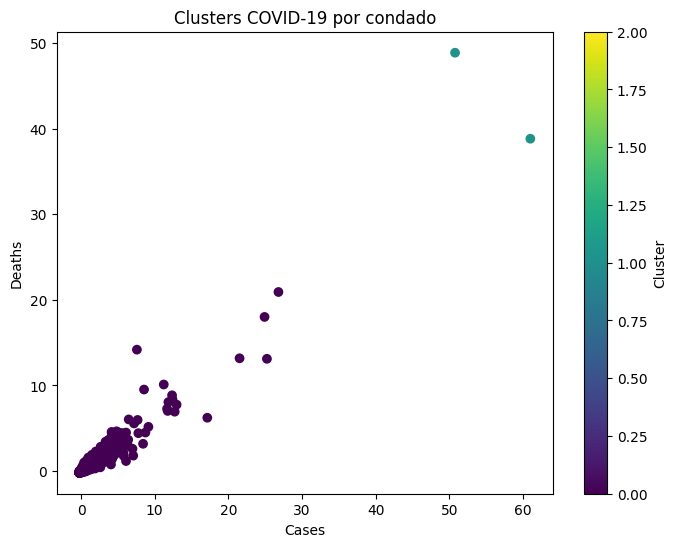

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_grouped["cases"],
    df_grouped["deaths"],
    c=df_grouped["cluster"],
    cmap="viridis"
)

plt.xlabel("Cases")
plt.ylabel("Deaths")
plt.title("Clusters COVID-19 por condado")

plt.colorbar(label="Cluster")
plt.show()

## **6.2 Scatter mejorado**

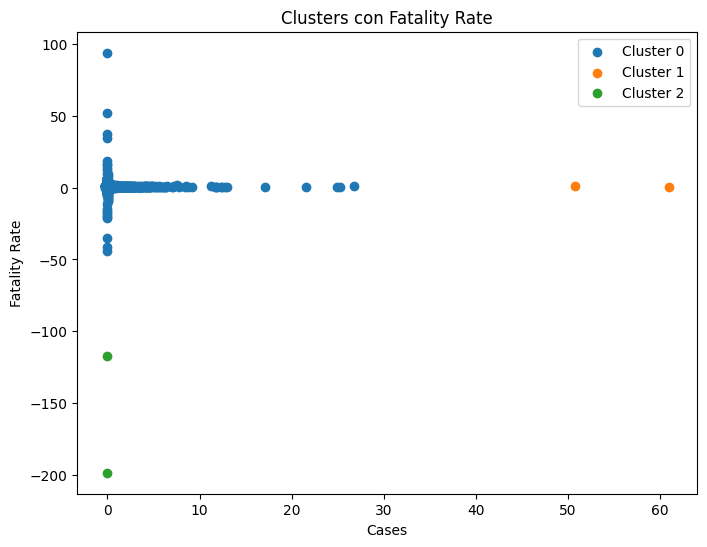

In [54]:
plt.figure(figsize=(8,6))

for cluster in df_grouped["cluster"].unique():
    subset = df_grouped[df_grouped["cluster"] == cluster]
    
    plt.scatter(
        subset["cases"],
        subset["fatality_rate"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Cases")
plt.ylabel("Fatality Rate")
plt.title("Clusters con Fatality Rate")
plt.legend()
plt.show()

## **6.3 Usando seaborn**

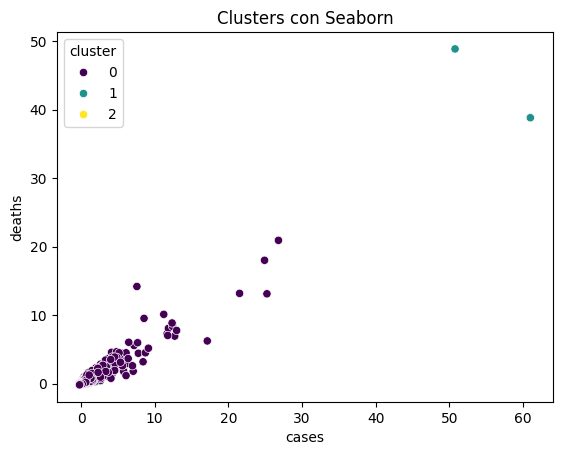

In [55]:
sns.scatterplot(
    data=df_grouped,
    x="cases",
    y="deaths",
    hue="cluster",
    palette="viridis"
)

plt.title("Clusters con Seaborn")
plt.show()

## **6.4 Dendrograma**

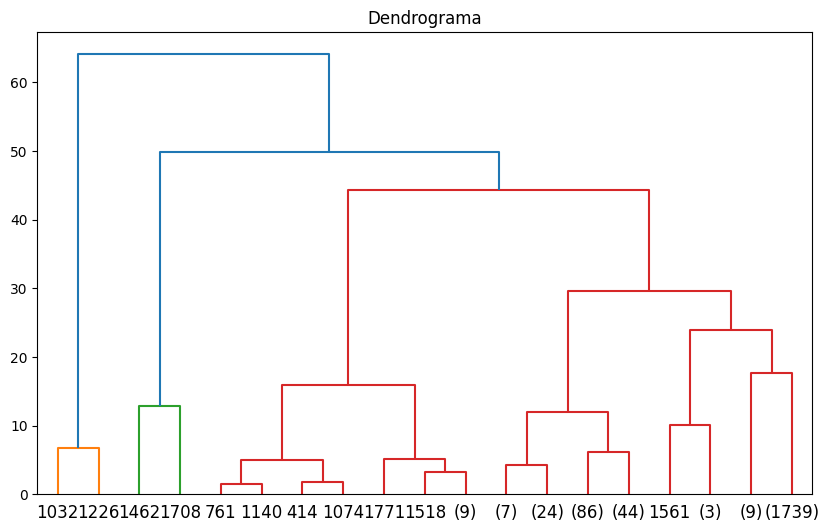

In [56]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Dendrograma")
plt.show()